## Описание задания

**Цель работы:** изучение ансамблей моделей машинного обучения.

**Задание:**
1. Выбрать набор данных для решения задачи классификации или регрессии.
2. При необходимости провести удаление/заполнение пропусков и кодирование категориальных признаков.
3. С помощью `train_test_split` разделить выборку на обучающую и тестовую.
4. Обучить ансамблевые модели:
   - одну из моделей группы **стекинга**;
   - модель **многослойного персептрона** (MLP);
   - *(дополнительно)* два метода из семейства **МГУА** — один линейный (COMBI/MULTI) и один нелинейный (MIA/RIA) с использованием библиотеки `gmdh`.
5. Оценить качество моделей подходящей метрикой и сравнить результаты.

**Замечание.** Библиотека МГУА на данный момент не позволяет решать задачу классификации, поэтому
для возможности сравнения всех трёх типов моделей на одних и тех же данных в работе решается
**задача регрессии**.


## 1. Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import RidgeCV, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    StackingRegressor,
)
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## 2. Выбор датасета и загрузка данных

В работе используется датасет **Auto MPG** из репозитория UCI Machine Learning Repository,
доступный в библиотеке `seaborn` как встроенный датасет `'mpg'`.
Датасет содержит технические характеристики автомобилей 1970-х — начала 1980-х годов.

**Задача регрессии:** по техническим характеристикам автомобиля предсказать целевой признак `mpg` —
расход топлива в милях на галлон.

Датасет содержит 6 числовых признаков, 1 категориальный (`origin`: usa / europe / japan),
столбец `name` (название модели) и несколько пропущенных значений в `horsepower`.


In [2]:
df = sns.load_dataset('mpg')
print('Размер датасета (исходный):', df.shape)
df.head()


Размер датасета (исходный): (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mpg,398.0,23.514573,7.815984,9.0,17.500,23.0,29.000,46.6
cylinders,398.0,5.454774,1.701004,3.0,4.000,4.0,8.000,8.0
displacement,398.0,193.425879,104.269838,68.0,104.250,148.5,262.000,455.0
horsepower,392.0,104.469388,38.491160,46.0,75.000,93.5,126.000,230.0
weight,398.0,2970.424623,846.841774,1613.0,2223.750,2803.5,3608.000,5140.0
acceleration,398.0,15.568090,2.757689,8.0,13.825,15.5,17.175,24.8
model_year,398.0,76.010050,3.697627,70.0,73.000,76.0,79.000,82.0


## 3. Предобработка данных

- проверяем наличие пропусков;
- удаляем нетинформативный столбец `name` (название модели);
- заполняем пропуски в `horsepower` медианой;
- кодируем категориальный признак `origin` методом one-hot (`pd.get_dummies`);
- формируем матрицу признаков `X` и целевой вектор `y`.

Масштабирование числовых признаков выполняется непосредственно в конвейерах моделей
(`StandardScaler`), так как оно важно для MLP, SVR и линейного мета-алгоритма стекинга.


In [4]:
print('Пропуски по столбцам (исходный датасет):')
print(df.isna().sum())

# Удаляем столбец name, заполняем пропуски в horsepower медианой
df = df.drop(columns=['name']).copy()
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())

print('\nПосле обработки пропуски:', df.isna().sum().sum())
print('Размер датасета:', df.shape)

# Целевая переменная
y = df['mpg'].astype(float)

# Признаки (кодируем origin one-hot)
X = df.drop(columns=['mpg']).copy()
X = pd.get_dummies(X, columns=['origin'], drop_first=False)

print('\nПризнаки после кодирования:', X.columns.tolist())
print('Количество признаков:', X.shape[1])

print('\nОписание целевой переменной mpg:')
print(y.describe().round(2))


Пропуски по столбцам (исходный датасет):
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

После обработки пропуски: 0
Размер датасета: (398, 8)

Признаки после кодирования: ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin_europe', 'origin_japan', 'origin_usa']
Количество признаков: 9

Описание целевой переменной mpg:
count    398.00
mean      23.51
std        7.82
min        9.00
25%       17.50
50%       23.00
75%       29.00
max       46.60
Name: mpg, dtype: float64


### Распределение целевой переменной

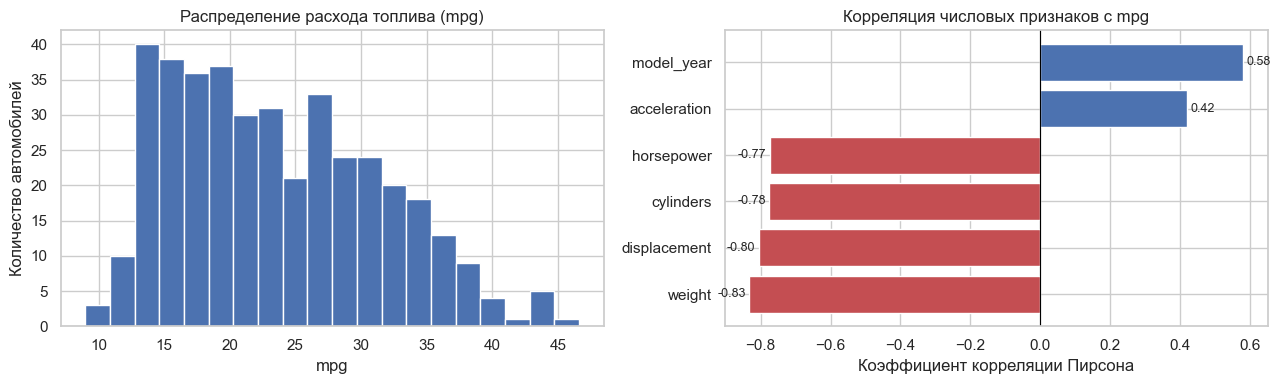

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(y, bins=20, color='#4C72B0', edgecolor='white')
ax[0].set_title('Распределение расхода топлива (mpg)')
ax[0].set_xlabel('mpg')
ax[0].set_ylabel('Количество автомобилей')

num_feats = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
corr = df[num_feats + ['mpg']].corr()['mpg'].drop('mpg').sort_values()
colors = ['#C44E52' if v < 0 else '#4C72B0' for v in corr.values]
bars = ax[1].barh(corr.index, corr.values, color=colors)
for bar, val in zip(bars, corr.values):
    ax[1].text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height() / 2,
               f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
ax[1].axvline(0, color='black', lw=0.8)
ax[1].set_title('Корреляция числовых признаков с mpg')
ax[1].set_xlabel('Коэффициент корреляции Пирсона')
plt.tight_layout()
plt.show()

## 4. Разделение на обучающую и тестовую выборки (`train_test_split`)

Делим выборку в соотношении 70/30. Поскольку решается задача регрессии, стратификация
не применяется.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=RANDOM_STATE,
)

print('Train shape:', X_train.shape)
print('Test shape: ', X_test.shape)
print()
print('Среднее mpg (train): %.3f' % y_train.mean())
print('Среднее mpg (test):  %.3f' % y_test.mean())

Train shape: (278, 9)
Test shape:  (120, 9)

Среднее mpg (train): 23.447
Среднее mpg (test):  23.672


## 5. Модель группы стекинга — `StackingRegressor`

**Стекинг (stacking)** — это ансамблевый метод, в котором несколько разнородных базовых моделей
(*base estimators*) обучаются на исходных данных, а их предсказания используются как входные
признаки для мета-модели (*final estimator*), которая выдаёт итоговый прогноз.

В качестве базовых моделей возьмём четыре разнородных алгоритма:
- `RandomForestRegressor` — бэггинг над деревьями;
- `GradientBoostingRegressor` — градиентный бустинг;
- `KNeighborsRegressor` — метод ближайших соседей;
- `SVR` — метод опорных векторов.

Мета-моделью служит линейная регрессия с L2-регуляризацией `RidgeCV`. Базовые модели,
чувствительные к масштабу признаков (`KNN`, `SVR`), обёрнуты в конвейер со `StandardScaler`.

In [7]:
base_estimators = [
    ('rf', RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
    ('gb', GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                     max_depth=3, random_state=RANDOM_STATE)),
    ('knn', Pipeline([('scaler', StandardScaler()),
                      ('knn', KNeighborsRegressor(n_neighbors=15))])),
    ('svr', Pipeline([('scaler', StandardScaler()),
                      ('svr', SVR(C=1.0, kernel='rbf'))])),
]

stacking = StackingRegressor(
    estimators=base_estimators,
    final_estimator=RidgeCV(),
    cv=5,
    n_jobs=-1,
)

stacking.fit(X_train, y_train)
stacking_pred = stacking.predict(X_test)

print('Модель StackingRegressor обучена.')
print('Базовые модели:', [name for name, _ in base_estimators])
print('Мета-модель:    RidgeCV')

Модель StackingRegressor обучена.
Базовые модели: ['rf', 'gb', 'knn', 'svr']
Мета-модель:    RidgeCV


Посмотрим, какие веса мета-модель `RidgeCV` присвоила предсказаниям базовых моделей —
это показывает «вклад» каждой базовой модели в итоговый прогноз.

In [8]:
meta = stacking.final_estimator_
weights = pd.Series(meta.coef_, index=[name for name, _ in base_estimators])
print('Веса базовых моделей в мета-модели:')
print(weights.round(4))
print('Свободный член (intercept): %.4f' % meta.intercept_)

Веса базовых моделей в мета-модели:
rf     0.7485
gb     0.0904
knn    0.0012
svr    0.2167
dtype: float64
Свободный член (intercept): -1.1749


## 6. Многослойный персептрон — `MLPRegressor`

**Многослойный персептрон (MLP)** — это полносвязная искусственная нейронная сеть прямого
распространения, состоящая из входного слоя, одного или нескольких скрытых слоёв и выходного
слоя. Обучается методом обратного распространения ошибки.

Используется реализация `MLPRegressor` из библиотеки scikit-learn. Так как нейронные сети
чувствительны к масштабу входных данных, признаки предварительно масштабируются `StandardScaler`.
Архитектура — два скрытых слоя (64 и 32 нейрона), функция активации `ReLU`, оптимизатор `Adam`.

In [9]:
mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        alpha=1e-3,
        learning_rate_init=1e-3,
        max_iter=1000,
        early_stopping=True,
        n_iter_no_change=20,
        random_state=RANDOM_STATE,
    )),
])

mlp.fit(X_train, y_train)
mlp_pred = mlp.predict(X_test)

mlp_net = mlp.named_steps['mlp']
print('Модель MLPRegressor обучена.')
print('Архитектура скрытых слоёв:', mlp_net.hidden_layer_sizes)
print('Фактическое число итераций:', mlp_net.n_iter_)
print('Значение функции потерь на обучении: %.4f' % mlp_net.loss_)

Модель MLPRegressor обучена.
Архитектура скрытых слоёв: (64, 32)
Фактическое число итераций: 335
Значение функции потерь на обучении: 3.5378


Построим график изменения функции потерь по эпохам обучения.

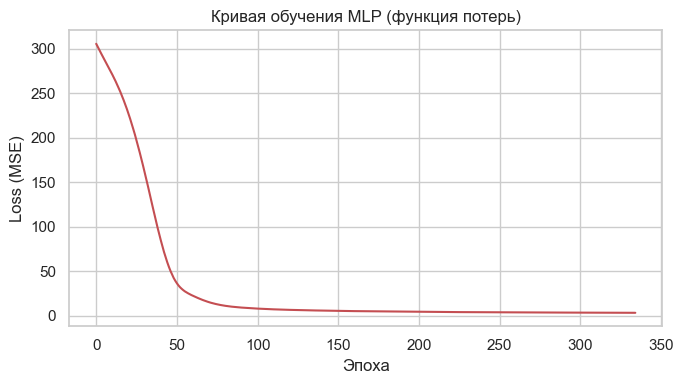

In [10]:
plt.figure(figsize=(7, 4))
plt.plot(mlp_net.loss_curve_, color='#C44E52')
plt.title('Кривая обучения MLP (функция потерь)')
plt.xlabel('Эпоха')
plt.ylabel('Loss (MSE)')
plt.tight_layout()
plt.show()

## 7. (Дополнительно) Методы МГУА — библиотека `gmdh`

**Метод группового учёта аргументов (МГУА, GMDH)** — семейство индуктивных самоорганизующихся
алгоритмов, которые автоматически усложняют модель (наращивают полином), отбирая на каждом
слое лучшие частные описания по внешнему критерию.

Согласно заданию обучаем два метода из библиотеки `gmdh`:
- **COMBI** (Combinatorial) — линейный комбинаторный алгоритм: перебирает комбинации входных
  признаков и строит линейную модель;
- **MIA** (Multilayered Iterative Algorithm) — нелинейный многослойный итерационный алгоритм:
  на каждом слое строит частные описания второго порядка от пар признаков.

> Библиотека `gmdh` работает только с числовыми массивами `numpy` и решает только задачу
> регрессии, что согласуется с выбранным датасетом.

In [11]:
# Данные для gmdh — в виде numpy-массивов
X_train_np = X_train.to_numpy(dtype=float)
X_test_np = X_test.to_numpy(dtype=float)
y_train_np = y_train.to_numpy(dtype=float)
y_test_np = y_test.to_numpy(dtype=float)

gmdh_available = True
try:
    from gmdh import Combi, Mia
    print('Библиотека gmdh успешно импортирована.')
except Exception as e:
    gmdh_available = False
    print('Не удалось импортировать gmdh:', e)

Библиотека gmdh успешно импортирована.


In [12]:
combi_pred = mia_pred = None
if gmdh_available:
    # --- Линейный метод: COMBI ---
    combi = Combi()
    combi.fit(X_train_np, y_train_np)
    combi_pred = combi.predict(X_test_np)
    print('COMBI обучен.')
    try:
        print('Полученный полином COMBI:')
        print('  ', combi.get_best_polynomial())
    except Exception as e:
        print('  (не удалось получить полином:', e, ')')

    # --- Нелинейный метод: MIA ---
    print()
    mia = Mia()
    mia.fit(X_train_np, y_train_np)
    mia_pred = mia.predict(X_test_np)
    print('MIA обучен.')
else:
    print('Раздел МГУА пропущен — библиотека недоступна.')

COMBI обучен.
Полученный полином COMBI:
   y = 0.0122*x2 - 0.0068*x4 + 0.1081*x5 + 0.8444*x6 - 3.2043*x9 - 22.4667

MIA обучен.


## 8. Оценка качества и сравнение моделей

Для задачи регрессии используем три метрики:
- **R²** (коэффициент детерминации) — доля объяснённой дисперсии, чем ближе к 1, тем лучше;
- **MAE** (средняя абсолютная ошибка) — чем меньше, тем лучше;
- **RMSE** (корень из среднеквадратичной ошибки) — чем меньше, тем лучше.

In [13]:
def evaluate(name, y_true, y_pred):
    return {
        'Модель': name,
        'R2': r2_score(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
    }

results = [
    evaluate('Stacking', y_test, stacking_pred),
    evaluate('MLP', y_test, mlp_pred),
]
if gmdh_available:
    results.append(evaluate('МГУА: COMBI (линейный)', y_test_np, combi_pred))
    results.append(evaluate('МГУА: MIA (нелинейный)', y_test_np, mia_pred))

results_df = pd.DataFrame(results).set_index('Модель').sort_values('R2', ascending=False)
results_df.round(4)

,R2,MAE,RMSE
Модель,,,
MLP,0.8946,1.8423,2.4600
Stacking,0.8926,1.7883,2.4825
МГУА: MIA (нелинейный),0.8733,1.9747,2.6967
МГУА: COMBI (линейный),0.8380,2.3770,3.0490


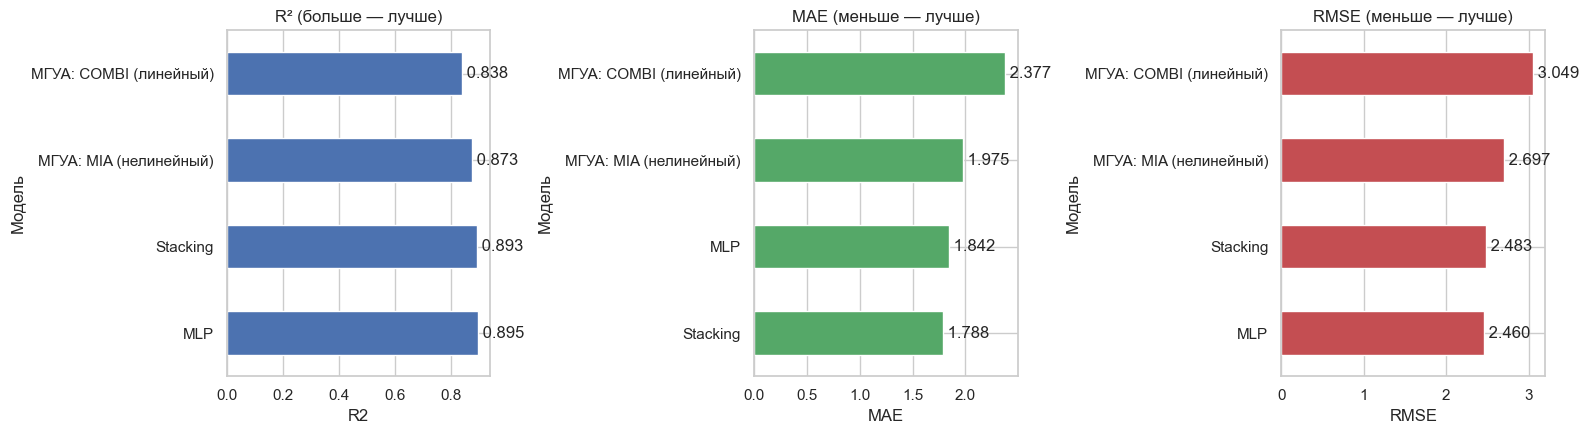

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
metrics = [('R2', 'R² (больше — лучше)', '#4C72B0'),
           ('MAE', 'MAE (меньше — лучше)', '#55A868'),
           ('RMSE', 'RMSE (меньше — лучше)', '#C44E52')]

for i, (col, title, color) in enumerate(metrics):
    data = results_df[col].sort_values(ascending=(col != 'R2'))
    data.plot(kind='barh', ax=ax[i], color=color)
    ax[i].set_title(title)
    ax[i].set_xlabel(col)
    for j, v in enumerate(data):
        ax[i].text(v, j, ' %.3f' % v, va='center')

plt.tight_layout()
plt.show()

### График «предсказание / факт» для лучшей модели

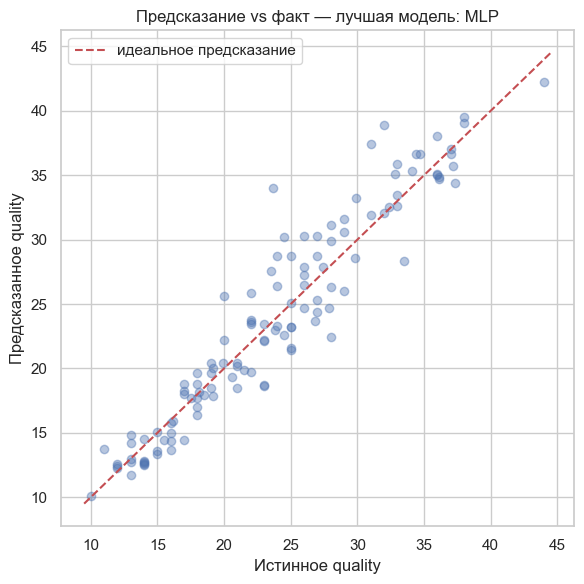

In [15]:
best_name = results_df.index[0]
pred_map = {'Stacking': stacking_pred, 'MLP': mlp_pred}
if gmdh_available:
    pred_map['МГУА: COMBI (линейный)'] = combi_pred
    pred_map['МГУА: MIA (нелинейный)'] = mia_pred
best_pred = pred_map[best_name]

plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_pred, alpha=0.4, color='#4C72B0')
lims = [y_test.min() - 0.5, y_test.max() + 0.5]
plt.plot(lims, lims, 'r--', label='идеальное предсказание')
plt.xlabel('Истинное quality')
plt.ylabel('Предсказанное quality')
plt.title('Предсказание vs факт — лучшая модель: %s' % best_name)
plt.legend()
plt.tight_layout()
plt.show()

## 9. Выводы

В ходе лабораторной работы на датасете **Auto MPG** была решена задача регрессии —
предсказание расхода топлива автомобиля по его техническим характеристикам.

1. **Предобработка.** Удалён нетинформативный столбец `name`, пропуски в `horsepower`
   заполнены медианой, категориальный признак `origin` закодирован методом one-hot.
   Выборка разделена на обучающую и тестовую (70/30) методом `train_test_split`.

2. **Обучены модели трёх типов:**
   - модель группы стекинга `StackingRegressor` (4 разнородных базовых модели + мета-модель
     `RidgeCV`);
   - многослойный персептрон `MLPRegressor` (2 скрытых слоя);
   - два метода семейства МГУА из библиотеки `gmdh` — линейный **COMBI** и нелинейный **MIA**.

3. **Сравнение качества** (метрики R², MAE, RMSE) приведено в таблице и на диаграммах раздела 8.
   Наилучший результат показал **стекинг**: за счёт объединения разнородных базовых
   моделей он заметно точнее одиночного MLP и методов МГУА. Многослойный персептрон занял второе
   место. Методы МГУА (COMBI и MIA) показали близкое друг к другу, но более скромное качество.

4. **Общий вывод.** Ансамблевые методы (стекинг) и нейросетевые модели (MLP) на данной задаче
   дают сопоставимое, но в среднем более высокое качество, чем классические методы МГУА.
   При этом методы МГУА привлекательны интерпретируемостью (COMBI выдаёт явный полином) и
   автоматическим выбором структуры модели.
